## Electric Vehicle Market Share Analysis

### 1. Data Cleaning

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r'D:\Data Analysis\1.Projects\5.Electirc Vehicle Market Share Analysis\Vehicle Data.csv')

In [5]:
df

,State,Electric (EV),Plug-In Hybrid Electric (PHEV),Hybrid Electric (HEV),Biodiesel,Ethanol/Flex (E85),Compressed Natural Gas (CNG),Propane,Hydrogen,Methanol,Gasoline,Diesel,Unknown Fuel
0,Alabama,"13,000","5,800","63,300","54,200","441,200",100,100,0,0,"4,102,200","127,000","29,000"
1,Alaska,"2,700",900,"10,600","9,600","46,800",0,0,0,0,"454,300","29,800","5,100"
2,Arizona,"89,800","25,600","175,700","68,600","437,100",600,700,0,0,"5,469,000","197,700","64,200"
3,Arkansas,"7,100","3,200","37,000","37,000","276,700",200,0,0,0,"2,246,100","90,700","10,300"
4,California,"1,256,600","410,700","1,703,200","201,600","1,314,600","10,100","1,500","16,900",0,"31,191,900","735,300","7,900"
5,Colorado,"90,100","37,500","152,700","68,100","334,300",300,100,0,0,"4,508,800","203,400","46,500"
6,Connecticut,"31,600","18,400","75,300","10,900","133,600",100,0,0,0,"2,612,600","42,300","20,900"
7,Delaware,"8,400","3,800","22,900","5,100","63,900",0,0,0,0,"791,300","14,200","5,100"
8,District of Columbia,"8,100","3,700","18,100",400,"16,800",100,0,0,0,"262,500","1,800",600
9,Florida,"254,900","57,300","414,500","170,500","1,101,100",400,100,0,0,"16,136,500","351,800","96,100"


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   State                           51 non-null     object
 1   Electric (EV)                   51 non-null     object
 2   Plug-In Hybrid Electric (PHEV)  51 non-null     object
 3   Hybrid Electric (HEV)           51 non-null     object
 4   Biodiesel                       51 non-null     object
 5   Ethanol/Flex (E85)              51 non-null     object
 6   Compressed Natural Gas (CNG)    51 non-null     object
 7   Propane                         51 non-null     object
 8   Hydrogen                        51 non-null     object
 9   Methanol                        51 non-null     int64 
 10  Gasoline                        51 non-null     object
 11  Diesel                          51 non-null     object
 12  Unknown Fuel                    51 non-null     obje

In [3]:
column_name = df.columns

In [4]:
import re

In [5]:
re.findall(r'\(([^)]+)\)','Plug-In Hybrid Electric')

[]

In [6]:
def extract_within_parentesis(text):

    if '(' in text:
         return re.findall(r'\(([^)]+)\)',text)[0]
    else:
         return text
    

In [11]:
extract_within_parentesis('Hydrogen')

'Hydrogen'

In [8]:
column_name_cleaned = []

In [9]:
for text in column_name:
    column_name_cleaned.append(extract_within_parentesis(text))

In [10]:
column_name_cleaned

['State',
 'EV',
 'PHEV',
 'HEV',
 'Biodiesel',
 'E85',
 'CNG',
 'Propane',
 'Hydrogen',
 'Methanol',
 'Gasoline',
 'Diesel',
 'Unknown Fuel']

In [11]:
df.columns = column_name_cleaned

In [12]:
df = df.drop('Methanol', axis = 1)

In [13]:
for col in df.columns[1:]:
    df[col] = df[col].str.replace(',','')

In [14]:
for col in df.columns[1:]:
    df[col] = df[col].astype('int64')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   State         51 non-null     object
 1   EV            51 non-null     int64 
 2   PHEV          51 non-null     int64 
 3   HEV           51 non-null     int64 
 4   Biodiesel     51 non-null     int64 
 5   E85           51 non-null     int64 
 6   CNG           51 non-null     int64 
 7   Propane       51 non-null     int64 
 8   Hydrogen      51 non-null     int64 
 9   Gasoline      51 non-null     int64 
 10  Diesel        51 non-null     int64 
 11  Unknown Fuel  51 non-null     int64 
dtypes: int64(11), object(1)
memory usage: 4.9+ KB


### Section 1 : Market Share Analysis

 Calculate the percentage of EVs, PHEVs, HEVs, and Gasoline vehicles for each state.

In [20]:
df['state_total'] = df.iloc[:,1:].sum(axis = 1)

In [21]:
df = df.rename(columns = {'state_total':'Total'})

In [22]:
df['pct_EV'] = (df['EV'] / df['Total'] * 100).round(2)
df['pct_PHEV'] = (df['PHEV'] / df['Total'] * 100).round(2)
df['pct_HEV'] = (df['HEV'] / df['Total'] * 100).round(2)
df['pct_Gasoline'] = (df['Gasoline'] / df['Total'] * 100).round(2)

In [59]:
df

,State,EV,PHEV,HEV,Biodiesel,E85,CNG,Propane,Hydrogen,Gasoline,Diesel,Unknown Fuel,Total,pct_EV,pct_PHEV,pct_HEV,pct_Gasoline
0,Alabama,13000,5800,63300,54200,441200,100,100,0,4102200,127000,29000,4835900,0.27,0.12,1.31,84.83
1,Alaska,2700,900,10600,9600,46800,0,0,0,454300,29800,5100,559800,0.48,0.16,1.89,81.15
2,Arizona,89800,25600,175700,68600,437100,600,700,0,5469000,197700,64200,6529000,1.38,0.39,2.69,83.76
3,Arkansas,7100,3200,37000,37000,276700,200,0,0,2246100,90700,10300,2708300,0.26,0.12,1.37,82.93
4,California,1256600,410700,1703200,201600,1314600,10100,1500,16900,31191900,735300,7900,36850300,3.41,1.11,4.62,84.64
5,Colorado,90100,37500,152700,68100,334300,300,100,0,4508800,203400,46500,5441800,1.66,0.69,2.81,82.85
6,Connecticut,31600,18400,75300,10900,133600,100,0,0,2612600,42300,20900,2945700,1.07,0.62,2.56,88.69
7,Delaware,8400,3800,22900,5100,63900,0,0,0,791300,14200,5100,914700,0.92,0.42,2.50,86.51
8,District of Columbia,8100,3700,18100,400,16800,100,0,0,262500,1800,600,312100,2.60,1.19,5.80,84.11
9,Florida,254900,57300,414500,170500,1101100,400,100,0,16136500,351800,96100,18583200,1.37,0.31,2.23,86.83


In [90]:
total_vehicle = df.iloc[:,1:12].sum(axis = 0)
df2 = pd.DataFrame(total_vehicle,columns = ['total_amount']).reset_index(names = 'fuel_types')
df2['pet_types'] = round(df2['total_amount']/sum(df2['total_amount']) * 100,2)
df2.sort_values(by = 'pet_types',ascending = False,inplace = True)
df2

,fuel_types,total_amount,pet_types
8,Gasoline,242870900,84.60
4,E85,20240600,7.05
2,HEV,7392300,2.57
9,Diesel,7184300,2.50
0,EV,3555900,1.24
3,Biodiesel,2803600,0.98
10,Unknown Fuel,1694100,0.59
1,PHEV,1307200,0.46
5,CNG,24700,0.01
7,Hydrogen,16900,0.01


#####
Identify the top 5 states with the highest EV adoption rate (EVs as a % of all registered vehicles).

In [24]:
df.sort_values('pct_EV',ascending = False).head(5)[['State','pct_EV']]

,State,pct_EV
4,California,3.41
8,District of Columbia,2.60
11,Hawaii,2.37
47,Washington,2.23
28,Nevada,1.85


Compare EV adoption in California vs. other large states (e.g., Texas, Florida, New York).

In [25]:
df[(df['State'] == 'California') | (df['State'] == 'Texas') | (df['State'] == 'Florida') | (df['State'] == 'New York')][['State','pct_EV']]

,State,pct_EV
4,California,3.41
9,Florida,1.37
32,New York,1.16
43,Texas,0.89


### Section 2 : Trend & Insights
Highlight which alternative fuels (biodiesel, ethanol, hydrogen) have meaningful presence vs. niche usage.

In [41]:
df.to_csv('Cleaned_Vehicle_Data.csv',index = False)

In [44]:
alternative_fuels = df[['State','Biodiesel','E85','Hydrogen']].iloc[:,1:].sum(axis = 0)

In [45]:
alternative_fuels

Biodiesel     2803600
E85          20240600
Hydrogen        16900
dtype: int64

Create visualizations (bar charts, pie charts, or maps) showing EV distribution by state.

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [60]:
# select top 15 state by total numbers of EVs

In [18]:
EV_top15 = df[['State','EV']].sort_values('EV', ascending = False).head(15)
EV_top15

,State,EV
4,California,1256600
9,Florida,254900
43,Texas,230100
47,Washington,152100
30,New Jersey,134800
32,New York,131300
13,Illinois,99600
10,Georgia,92400
5,Colorado,90100
2,Arizona,89800


Text(0, 0.5, '')

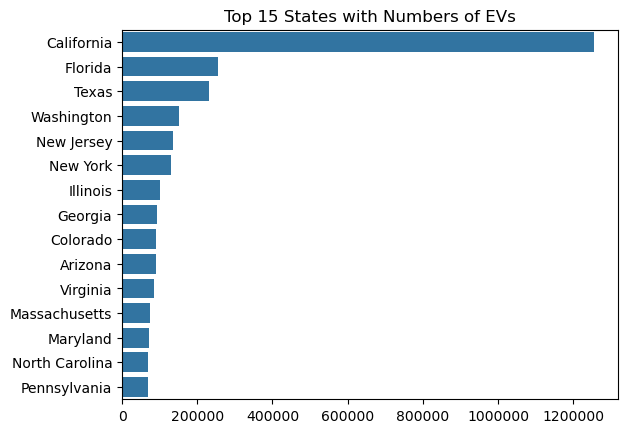

In [21]:
sns.barplot(EV_top15, y = 'State', x = 'EV')
plt.plot
plt.title('Top 15 States with Numbers of EVs')
plt.ticklabel_format(style='plain', axis='x')
plt.xlabel("") 
plt.ylabel("")


## Conclusion

This analysis confirms that gasoline still dominates the U.S. automotive market (about 84.4%), but there is a clear regional stratification in the field of electrification. Market leaders: states such as California (3.41%) have reached maturity and now require investments to ensure network reliability and densification. Growth opportunities: The states with the largest volume of investments, especially Texas (0.90%), have the largest gap in penetration, making them the most important sites for growth-oriented infrastructure.